# Sentiment Classification with DistilBERT

### Requirements


This notebook presents the complete experimental pipeline for sentiment classification on the IMDb movie review dataset using a pretrained DistilBERT model. It covers the main stages of the project, from exploratory data analysis and data preprocessing to model training and evaluation. Two transfer-learning strategies are investigated: fine-tuning the pretrained DistilBERT encoder and freezing the encoder while training only the classification head. The notebook keeps the main configurations, training outputs, evaluation metrics, and visualizations used to analyze and compare both approaches. The experiments are conducted using a fixed random seed to improve reproducibility.





In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib seaborn

In [ ]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


#### Settings



* MODEL_NAME = "distilbert-base-uncased"

* TRAIN_SIZE = 4000
* VAL_SIZE = 1000
* TEST_SIZE = 1000

* MAX_LENGTH = 256

* LEARNING_RATE = 5e-5
* BATCH_SIZE = 16
* EPOCHS = 2
* WEIGHT_DECAY = 0.01

### Dataset (IMDb)

In [ ]:
# Load dataset

from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

dataset

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
print(dataset["train"][0])
print(dataset["train"][1])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
print(dataset["train"].features["label"])

ClassLabel(names=['neg', 'pos'])


### Exploratory Data Analysis

#### Class Dist

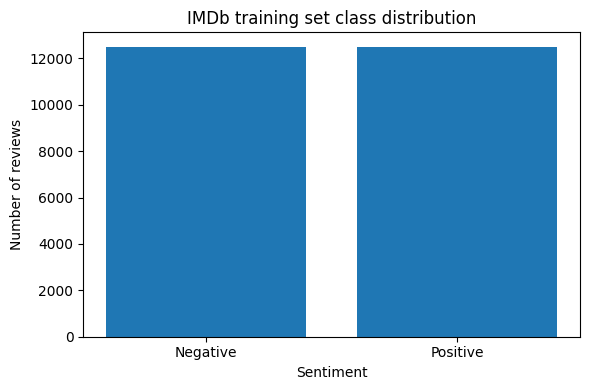

In [43]:
import matplotlib.pyplot as plt

label_counts = dataset["train"].to_pandas()["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Negative", "Positive"], label_counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.title("IMDb training set class distribution")
plt.tight_layout()
plt.show()

#### Length Dist

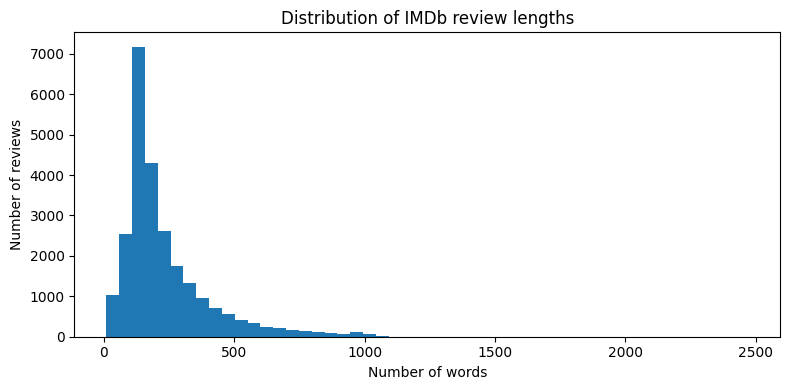

In [49]:
import matplotlib.pyplot as plt

train_df = dataset["train"].to_pandas()
train_df["text_length"] = train_df["text"].str.split().str.len()

plt.figure(figsize=(8, 4))
plt.hist(train_df["text_length"], bins=50)
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.title("Distribution of IMDb review lengths")
plt.tight_layout()
plt.show()

In [51]:
train_df["text_length"].describe()

,text_length
count,25000.000000
mean,233.787200
std,173.733032
min,10.000000
25%,127.000000
50%,174.000000
75%,284.000000
max,2470.000000


### Data Preprocessing

#### Data split

In [ ]:
# retrieve an experimental subset

train_size = 5000
val_size = 1000
test_size = 1000

train_dataset = dataset["train"].shuffle(seed=SEED).select(range(train_size))
test_dataset = dataset["test"].shuffle(seed=SEED).select(range(test_size))

split = train_dataset.train_test_split(
    test_size=val_size,
    seed=SEED
)

train_dataset = split["train"]
val_dataset = split["test"]

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

In [8]:
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(train_dataset[i]["text"][:1000])
    print("Label:", "Positive" if train_dataset[i]["label"] == 1 else "Negative")


--- Example 1 ---
This movie is just truly awful, the eye-candy that plays Ben just can make up for everything else that is wrong with this movie.<br /><br />The writer/director/producer/lead actor etc probably had a good idea to create a movie dealing with the important issues of gay marriage, family acceptance, religion, homophobia, hate crimes and just about every other issue effecting a gay man of these times, but trying to ram every issue into such a poorly conceived film does little justice to any of these causes.<br /><br />The script is poor, the casting very ordinary, but the dialogue and acting is just woeful. The homo-hating brother is played by the most camp actor and there is absolutely no chemistry between the two lead actors (I think I've seen more passion in an corn flakes ad). The acting is stiff, and the dialogue forced (a scene where the brother is feeding the detective his lines was the highlight).<br /><br />I'm just pleased to see that the creator of this train w

#### Tokenization

In [9]:


from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [10]:
MAX_LENGTH = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

In [11]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [12]:
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

### Model Training

#### The Model

In [13]:

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print(model)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [15]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


#### Metrics

In [16]:
# Our evaluation  metrics
import evaluate

accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

In [17]:
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(
            predictions=predictions,
            references=labels
        )["accuracy"],

        "precision": precision.compute(
            predictions=predictions,
            references=labels,
            average="binary"
        )["precision"],

        "recall": recall.compute(
            predictions=predictions,
            references=labels,
            average="binary"
        )["recall"],

        "f1": f1.compute(
            predictions=predictions,
            references=labels,
            average="binary"
        )["f1"],
    }

#### Experiment 1: Fine-tuned DistilBERT

In [19]:
# Training configuration

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    fp16=True,
    seed=SEED
)

In [20]:
# Setup of the trainer

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [21]:
import time

start_time = time.time()

train_result = trainer.train()

training_time = time.time() - start_time

print(f"Training time: {training_time / 60:.2f} minutes")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.361524,0.297650,0.881000,0.898089,0.856275,0.876684
2,0.191746,0.347404,0.889000,0.893224,0.880567,0.886850


Training time: 0.95 minutes


In [22]:
# EValuation
eval_results = trainer.evaluate(tokenized_test)

print(eval_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.191746,0.349824,2,0.878000,0.879668,0.868852,0.874227


{'eval_loss': 0.34982433915138245, 'eval_accuracy': 0.878, 'eval_precision': 0.8796680497925311, 'eval_recall': 0.8688524590163934, 'eval_f1': 0.8742268041237113}


In [23]:
baseline_results = {
    "model": "DistilBERT",
    "strategy": "Fine-tuning",
    "learning_rate": 5e-5,
    "epochs": 2,
    "train_samples": len(tokenized_train),
    "validation_samples": len(tokenized_val),
    "test_samples": len(tokenized_test),
    "accuracy": eval_results["eval_accuracy"],
    "precision": eval_results["eval_precision"],
    "recall": eval_results["eval_recall"],
    "f1": eval_results["eval_f1"],
    "training_time_minutes": training_time / 60
}

baseline_results

{'model': 'DistilBERT',
 'strategy': 'Fine-tuning',
 'learning_rate': 5e-05,
 'epochs': 2,
 'train_samples': 4000,
 'validation_samples': 1000,
 'test_samples': 1000,
 'accuracy': 0.878,
 'precision': 0.8796680497925311,
 'recall': 0.8688524590163934,
 'f1': 0.8742268041237113,
 'training_time_minutes': 0.9548750519752502}

As we have  credible results on the average, we want to answer:

Is fine-tuning the pretrained DistilBERT representations beneficial compared with using them as frozen features?

#### Experiment 2: Frozen DistilBERT

In [24]:


from transformers import AutoModelForSequenceClassification

frozen_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
for param in frozen_model.distilbert.parameters():
    param.requires_grad = False

In [26]:
total_params = sum(p.numel() for p in frozen_model.parameters())
trainable_params = sum(
    p.numel() for p in frozen_model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {100 * trainable_params / total_params:.2f}%")

Total parameters: 66,955,010
Trainable parameters: 592,130
Trainable percentage: 0.88%


In [27]:
# Training of the frozen model

frozen_training_args = TrainingArguments(
    output_dir="./results_frozen",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    fp16=True,
    seed=SEED
)

In [28]:
# Setup of the trainer

frozen_trainer = Trainer(
    model=frozen_model,
    args=frozen_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [32]:
start_time = time.time()

frozen_train_result = frozen_trainer.train()

frozen_training_time = time.time() - start_time

print(f"Training time: {frozen_training_time / 60:.2f} minutes")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.598141,0.584046,0.764000,0.720137,0.854251,0.781481
2,0.556168,0.544063,0.785000,0.787629,0.773279,0.780388


Training time: 0.53 minutes


In [33]:
frozen_test_results = frozen_trainer.evaluate(tokenized_test)

print(frozen_test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.556168,0.549273,2,0.793000,0.777120,0.807377,0.791960


{'eval_loss': 0.5492727160453796, 'eval_accuracy': 0.793, 'eval_precision': 0.777120315581854, 'eval_recall': 0.8073770491803278, 'eval_f1': 0.7919597989949749}


### Model Evaluation

#### Comparison table

In [35]:
# Fine-tuned model on test set
finetuned_test_results = trainer.evaluate(tokenized_test)

# Frozen model on test set
frozen_test_results = frozen_trainer.evaluate(tokenized_test)

print("Fine-tuned:")
print(finetuned_test_results)

print("\nFrozen:")
print(frozen_test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.191746,0.349824,2,0.878000,0.879668,0.868852,0.874227


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.556168,0.549273,2,0.793000,0.777120,0.807377,0.791960


Fine-tuned:
{'eval_loss': 0.34982433915138245, 'eval_accuracy': 0.878, 'eval_precision': 0.8796680497925311, 'eval_recall': 0.8688524590163934, 'eval_f1': 0.8742268041237113}

Frozen:
{'eval_loss': 0.5492727160453796, 'eval_accuracy': 0.793, 'eval_precision': 0.777120315581854, 'eval_recall': 0.8073770491803278, 'eval_f1': 0.7919597989949749}


In [36]:
# results table

import pandas as pd

results_df = pd.DataFrame([
    {
        "Strategy": "Fine-tuning",
        "Accuracy": finetuned_test_results["eval_accuracy"],
        "Precision": finetuned_test_results["eval_precision"],
        "Recall": finetuned_test_results["eval_recall"],
        "F1": finetuned_test_results["eval_f1"],
    },
    {
        "Strategy": "Frozen encoder",
        "Accuracy": frozen_test_results["eval_accuracy"],
        "Precision": frozen_test_results["eval_precision"],
        "Recall": frozen_test_results["eval_recall"],
        "F1": frozen_test_results["eval_f1"],
    }
])

results_df

,Strategy,Accuracy,Precision,Recall,F1
0,Fine-tuning,0.878,0.879668,0.868852,0.874227
1,Frozen encoder,0.793,0.777120,0.807377,0.791960


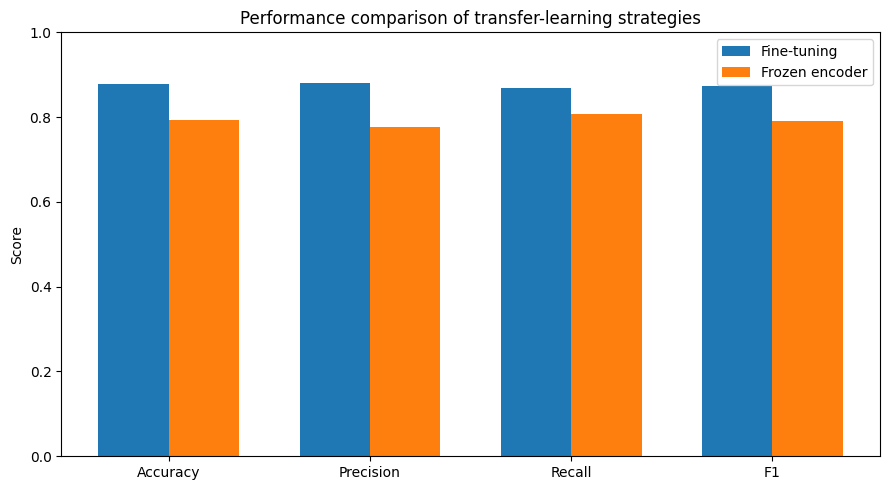

In [37]:
# Comparison plot

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    results_df.iloc[0][metrics],
    width,
    label="Fine-tuning"
)

plt.bar(
    x + width/2,
    results_df.iloc[1][metrics],
    width,
    label="Frozen encoder"
)

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Performance comparison of transfer-learning strategies")
plt.legend()
plt.tight_layout()
plt.show()

#### Confusion matrices

In [39]:
# get confusion matrices

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(trainer, dataset, title):
    predictions = trainer.predict(dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = predictions.label_ids

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot()
    plt.title(title)
    plt.tight_layout()
    plt.show()



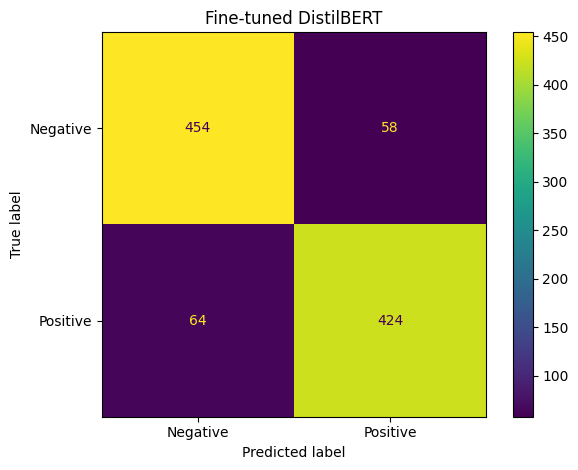

In [41]:
plot_confusion_matrix(
    trainer,
    tokenized_test,
    "Fine-tuned DistilBERT"
)

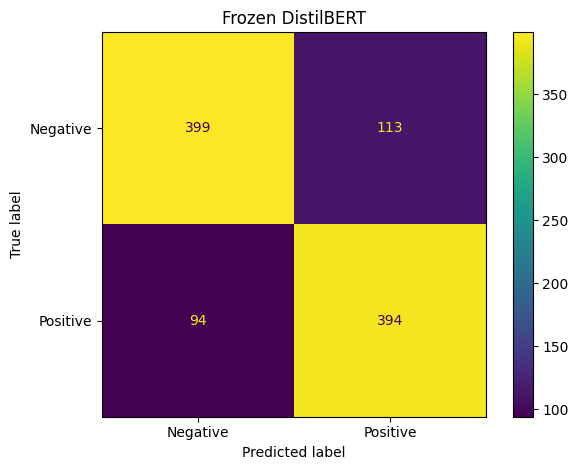

In [40]:
plot_confusion_matrix(
    frozen_trainer,
    tokenized_test,
    "Frozen DistilBERT"
)

### Conclusion

The results show a clear difference between the two transfer-learning strategies. Fine-tuning achieves an accuracy of 87.8% and an F1-score of 87.4%, compared with 79.3% accuracy and 79.2% F1-score for the frozen encoder. Fine-tuning therefore provides an improvement of 8.5 percentage points in accuracy and 7.4 percentage points in F1-score. The frozen strategy nevertheless achieves slightly higher recall (80.7% compared with 86.9% for fine-tuning), while fine-tuning provides substantially higher precision. These results suggest that adapting the pretrained DistilBERT representations to the sentiment classification task improves overall predictive performance.
